# 🛍️ Customer Segmentation with RFM Analysis and K-Means

## Business Objective

A company wants to segment its customer base in order to support **targeted marketing** and better understand customer buying behavior.

This project follows the assignment requirements:

1. Import the original dataset
2. Create three DataFrames: **Customers**, **Products**, and **Orders**
3. Insert the three DataFrames into a **SQLite database**
4. Read the tables back from SQLite and merge them into one DataFrame
5. Create an **RFM table**
6. Segment customers using **K-Means clustering**
7. Justify the selected number of customer segments
8. Describe the characteristics of each segment

The final goal is to identify meaningful customer groups that can support different marketing strategies.

## RFM Analysis

**RFM** is a customer segmentation technique based on three measures:

- **Recency (R):** How recently did the customer purchase?
- **Frequency (F):** How often did the customer purchase?
- **Monetary (M):** How much did the customer spend?

In general:

- Lower Recency is better because the customer purchased more recently.
- Higher Frequency indicates more repeat purchases.
- Higher Monetary indicates higher total spending.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [36]:
df = pd.read_csv(
    "PBL5recommendationdata.csv",
    encoding="latin-1",
    low_memory=False
)

df.head()

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,...,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
0,797,Christy,Dill,Company0,1426018724,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF61071,0.0,NaN
1,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF02132,NaN,NaN
2,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2 x Extra large,Nitrile,NaN,NaN,NaN,PF00342,0.0,NaN
3,4,James,Anderson,NaN,1386780263,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF04970,NaN,NaN
4,5,Abraham,Pollak,Company3,1386861599,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF03045,NaN,NaN


## Exploratory Data Analysis

In [37]:
df.shape

(4194, 181)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Columns: 181 entries, Customers.id to Products.freight_cost
dtypes: float64(98), int64(10), str(73)
memory usage: 11.0 MB


In [39]:
df.isnull().sum().sort_values(ascending=False).head(20)

Customers.reminders             4194
Customers.sales_rep             4194
Customers.rewards               4194
Customers.profile_id            4194
Orders.sales_rep                4194
Orders.shipping_flags           4194
Orders.gift_id                  4194
Orders.purchase_order           4194
Orders.shipping_trans           4194
Orders.gift_amount              4194
Products.menu_name              4194
Order_Items.account_id          4194
Order_Items.registry_item       4194
Order_Items.attributes          4194
Order_Items.attribute_prices    4194
Order_Items.related_id          4194
Orders.mailing                  4194
Orders.registry_id              4194
Orders.gift_message             4194
Orders.website                  4194
dtype: int64

The original file is a wide table containing customer, order, order-item, and product information.  
The column prefixes are used to separate the data into the required business tables.

In [40]:
customer_columns = [col for col in df.columns if col.startswith("Customers.")]
order_columns = [col for col in df.columns if col.startswith("Orders.")]
product_columns = [col for col in df.columns if col.startswith("Products.")]
order_item_columns = [col for col in df.columns if col.startswith("Order_Items.")]

print("Customer columns:", len(customer_columns))
print("Order columns:", len(order_columns))
print("Product columns:", len(product_columns))
print("Order item columns:", len(order_item_columns))

Customer columns: 15
Order columns: 53
Product columns: 98
Order item columns: 15


## Create Customers, Orders and Products DataFrames

Only the fields needed for customer analysis, order history, product information, and table relationships are selected.

Order-item product information is included in the Orders DataFrame so that orders can be linked to products after the tables are imported from SQLite.

In [41]:
customers_df = df[[
    "Customers.id",
    "Customers.fname",
    "Customers.lname",
    "Customers.company",
    "Customers.status",
    "Customers.customer_type",
    "Customers.create_date",
    "Customers.last_modified"
]].copy()

customers_df.columns = [
    "customer_id",
    "first_name",
    "last_name",
    "company",
    "customer_status",
    "customer_type",
    "create_date",
    "last_modified"
]

customers_df = customers_df.drop_duplicates(
    subset="customer_id"
).reset_index(drop=True)

customers_df.head()

,customer_id,first_name,last_name,company,customer_status,customer_type,create_date,last_modified
0,797,Christy,Dill,Company0,NaN,0.0,1426018724,1437764306
1,3,John,Smith,Company1,NaN,0.0,1386089139,1437764354
2,4,James,Anderson,NaN,NaN,0.0,1386780263,1437762646
3,5,Abraham,Pollak,Company3,0.0,0.0,1386861599,1437764316
4,7,peggy,thompson,NaN,NaN,0.0,1388155947,1437763617


In [42]:
orders_df = df[[
    "Orders.id",
    "Orders.customer_id",
    "Orders.order_number",
    "Orders.subtotal",
    "Orders.tax",
    "Orders.shipping",
    "Orders.total",
    "Orders.status",
    "Orders.placed_date",
    "Orders.payment_status",
    "Orders.payment_method",
    "Order_Items.product_id",
    "Order_Items.qty",
    "Order_Items.price"
]].copy()

orders_df.columns = [
    "order_id",
    "customer_id",
    "order_number",
    "subtotal",
    "tax",
    "shipping",
    "order_total",
    "order_status",
    "placed_date",
    "payment_status",
    "payment_method",
    "product_id",
    "quantity",
    "item_price"
]

orders_df.head()

,order_id,customer_id,order_number,subtotal,tax,shipping,order_total,order_status,placed_date,payment_status,payment_method,product_id,quantity,item_price
0,3758,797,3758,57.20,0.0,9.95,64.29,1,1426019099,3.0,NaN,2310.0,1,57.20
1,23,3,23,20.00,NaN,9.99,29.99,1,1386090455,3.0,NaN,177.0,4,5.00
2,9531,3,9531,68.78,0.0,9.95,78.73,3,1449603652,3.0,NaN,1.0,1,68.78
3,29,4,29,19.56,0.0,9.95,29.55,1,1386780263,3.0,Credit Card,983.0,1,19.56
4,30,5,30,36.05,NaN,9.95,46.00,1,1386861599,3.0,Credit Card,991.0,1,36.05


In [43]:
products_df = df[[
    "Products.id",
    "Products.name",
    "Products.display_name",
    "Products.product_type",
    "Products.vendor",
    "Products.list_price",
    "Products.price",
    "Products.sale_price",
    "Products.cost",
    "Products.status"
]].copy()

products_df.columns = [
    "product_id",
    "product_name",
    "display_name",
    "product_type",
    "vendor",
    "list_price",
    "product_price",
    "sale_price",
    "product_cost",
    "product_status"
]

products_df = (
    products_df
    .dropna(subset=["product_id"])
    .drop_duplicates(subset="product_id")
    .reset_index(drop=True)
)

products_df.head()

,product_id,product_name,display_name,product_type,vendor,list_price,product_price,sale_price,product_cost,product_status
0,2310.0,"Basic Steel Rollators,Green","Basic Lightweight Rollators For Adults, With S...",NaN,1.0,80.70,57.64,NaN,44.00,0.0
1,177.0,Urinary Drain Bags,Urinary Drain Bags,NaN,1.0,14.41,10.29,5.0,1.87,1.0
2,1.0,"SensiCare Nitrile Exam Gloves,Blue,XX-Large","SensiCare Nitrile Exam Gloves, Blue, XX-Large",NaN,1.0,96.29,68.78,NaN,52.50,0.0
3,983.0,Basket for 2-Button Walkers,Basket for 2-Button Walkers,NaN,1.0,27.38,19.56,NaN,12.62,0.0
4,991.0,TENS 3000 Analog Unit,TENS 3000 Analog Unit,NaN,1.0,50.47,36.05,NaN,25.75,1.0


In [44]:
print("Customers:", customers_df.shape)
print("Orders / order-item rows:", orders_df.shape)
print("Products:", products_df.shape)

Customers: (3054, 8)
Orders / order-item rows: (4194, 14)
Products: (1710, 10)


## SQLite Database

The three DataFrames are stored in a SQLite database as required by the assignment

In [45]:
conn = sqlite3.connect("customer_segmentation.db")

customers_df.to_sql(
    "Customers",
    conn,
    if_exists="replace",
    index=False
)

orders_df.to_sql(
    "Orders",
    conn,
    if_exists="replace",
    index=False
)

products_df.to_sql(
    "Products",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("Three tables were written to the SQLite database.")

Three tables were written to the SQLite database.


## Import Tables from SQLite

In [46]:
conn = sqlite3.connect("customer_segmentation.db")

customers_sql = pd.read_sql_query(
    "SELECT * FROM Customers",
    conn
)

orders_sql = pd.read_sql_query(
    "SELECT * FROM Orders",
    conn
)

products_sql = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)

conn.close()

print("Customers:", customers_sql.shape)
print("Orders:", orders_sql.shape)
print("Products:", products_sql.shape)

Customers: (3054, 8)
Orders: (4194, 14)
Products: (1710, 10)


## Merge the Tables

In [47]:
merged_df = orders_sql.merge(
    customers_sql,
    on="customer_id",
    how="left"
)

merged_df = merged_df.merge(
    products_sql,
    on="product_id",
    how="left"
)

merged_df.head()

,order_id,customer_id,order_number,subtotal,tax,shipping,order_total,order_status,placed_date,payment_status,...,last_modified,product_name,display_name,product_type,vendor,list_price,product_price,sale_price,product_cost,product_status
0,3758,797,3758,57.20,0.0,9.95,64.29,1,1426019099,3.0,...,1437764306,"Basic Steel Rollators,Green","Basic Lightweight Rollators For Adults, With S...",None,1.0,80.70,57.64,NaN,44.00,0.0
1,23,3,23,20.00,NaN,9.99,29.99,1,1386090455,3.0,...,1437764354,Urinary Drain Bags,Urinary Drain Bags,None,1.0,14.41,10.29,5.0,1.87,1.0
2,9531,3,9531,68.78,0.0,9.95,78.73,3,1449603652,3.0,...,1437764354,"SensiCare Nitrile Exam Gloves,Blue,XX-Large","SensiCare Nitrile Exam Gloves, Blue, XX-Large",None,1.0,96.29,68.78,NaN,52.50,0.0
3,29,4,29,19.56,0.0,9.95,29.55,1,1386780263,3.0,...,1437762646,Basket for 2-Button Walkers,Basket for 2-Button Walkers,None,1.0,27.38,19.56,NaN,12.62,0.0
4,30,5,30,36.05,NaN,9.95,46.00,1,1386861599,3.0,...,1437764316,TENS 3000 Analog Unit,TENS 3000 Analog Unit,None,1.0,50.47,36.05,NaN,25.75,1.0


In [48]:
merged_df.shape

(4194, 30)

## Date Preparation

The order dates are stored as Unix timestamps. They are converted into standard datetime values before calculating Recency.

In [49]:
merged_df["placed_date"] = pd.to_datetime(
    pd.to_numeric(
        merged_df["placed_date"],
        errors="coerce"
    ),
    unit="s",
    errors="coerce"
)

merged_df[[
    "order_id",
    "customer_id",
    "placed_date",
    "order_total"
]].head()

,order_id,customer_id,placed_date,order_total
0,3758,797,2015-03-10 20:24:59,64.29
1,23,3,2013-12-03 17:07:35,29.99
2,9531,3,2015-12-08 19:40:52,78.73
3,29,4,2013-12-11 16:44:23,29.55
4,30,5,2013-12-12 15:19:59,46.00


In [50]:
print("First order date:", merged_df["placed_date"].min())
print("Last order date:", merged_df["placed_date"].max())

First order date: 2013-12-03 17:07:35
Last order date: 2016-05-16 17:14:39


## Create the RFM Table

An order may appear more than once because one order can contain multiple products.

For the RFM calculation, each order must therefore be counted only once.  
A separate order-level table is created before calculating Frequency and Monetary values.

Because this is a historical dataset, Recency is calculated relative to **one day after the latest order in the dataset**, rather than today's date.

In [51]:
order_level = merged_df[[
    "order_id",
    "customer_id",
    "placed_date",
    "order_total"
]].drop_duplicates(
    subset="order_id"
).copy()

order_level = order_level.dropna(
    subset=[
        "customer_id",
        "placed_date",
        "order_total"
    ]
)

order_level.head()

,order_id,customer_id,placed_date,order_total
0,3758,797,2015-03-10 20:24:59,64.29
1,23,3,2013-12-03 17:07:35,29.99
2,9531,3,2015-12-08 19:40:52,78.73
3,29,4,2013-12-11 16:44:23,29.55
4,30,5,2013-12-12 15:19:59,46.00


In [52]:
snapshot_date = (
    order_level["placed_date"].max().normalize()
    + pd.Timedelta(days=1)
)

print("RFM snapshot date:", snapshot_date)

RFM snapshot date: 2016-05-17 00:00:00


In [53]:
rfm_df = order_level.groupby(
    "customer_id"
).agg(
    LastPurchase=("placed_date", "max"),
    Frequency=("order_id", "nunique"),
    Monetary=("order_total", "sum")
).reset_index()

rfm_df["Recency"] = (
    snapshot_date - rfm_df["LastPurchase"]
).dt.days

rfm_df = rfm_df[[
    "customer_id",
    "Recency",
    "Frequency",
    "Monetary"
]]

rfm_df.head()

,customer_id,Recency,Frequency,Monetary
0,3,160,2,108.72
1,4,887,1,29.55
2,5,614,3,124.99
3,7,871,1,49.14
4,8,858,1,69.70


In [54]:
rfm_df[[
    "Recency",
    "Frequency",
    "Monetary"
]].describe().round(2)

,Recency,Frequency,Monetary
count,3054.00,3054.00,3054.00
mean,231.03,1.17,134.67
std,212.76,0.93,337.65
min,0.00,1.00,2.89
25%,58.25,1.00,38.97
50%,147.00,1.00,69.60
75%,364.00,1.00,129.99
max,887.00,18.00,10007.48


## RFM Visualization

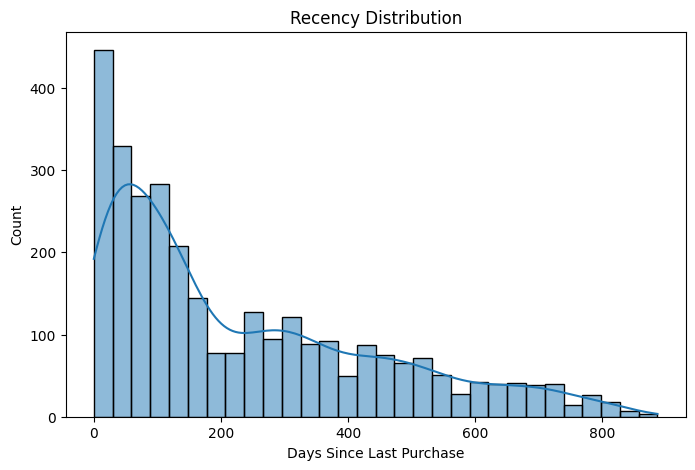

In [55]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm_df["Recency"],
    bins=30,
    kde=True
)

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()

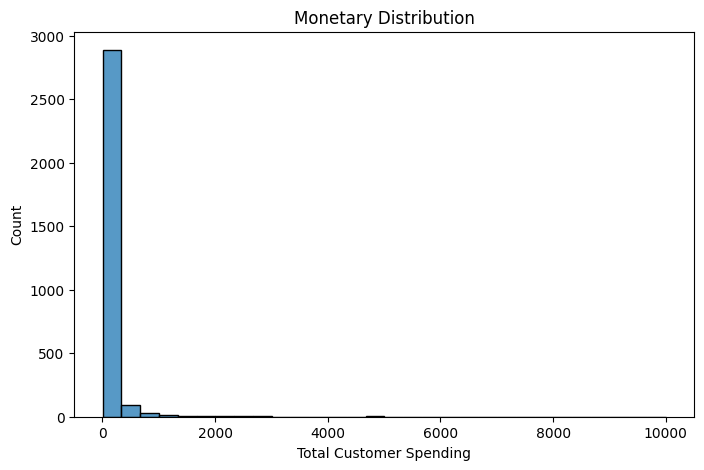

In [56]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm_df["Monetary"],
    bins=30
)

plt.title("Monetary Distribution")
plt.xlabel("Total Customer Spending")
plt.show()

## Prepare RFM Features for Clustering

K-Means is distance-based, so the RFM variables are standardized before clustering.  
This prevents variables with larger numerical values from dominating the model.

In [57]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm_df[[
    "Recency",
    "Frequency",
    "Monetary"
]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_features
)

rfm_scaled[:5]

array([[-0.33389246,  0.89263788, -0.07686491],
       [ 3.08370157, -0.17937002, -0.31137966],
       [ 1.80034095,  1.96464579, -0.02867046],
       [ 3.0084863 , -0.17937002, -0.25335081],
       [ 2.94737389, -0.17937002, -0.19244866]])

## Selecting the Number of Clusters

The number of clusters is evaluated using two methods:

- **Elbow Method:** compares Within-Cluster Sum of Squares (WCSS)
- **Silhouette Score:** measures how well customers fit within their assigned clusters

Testing several values of `k` provides a more justified choice than selecting the number of clusters manually.

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

k_values = range(2, 10)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        rfm_scaled
    )

    wcss.append(
        model.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            rfm_scaled,
            labels
        )
    )

scores_df = pd.DataFrame({
    "k": list(k_values),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

scores_df.round(4)

,k,WCSS,Silhouette Score
0,2,6001.6725,0.8796
1,3,3733.5261,0.5540
2,4,2950.9102,0.5743
3,5,2415.8032,0.5749
4,6,1988.4346,0.5104
5,7,1557.7361,0.5180
6,8,1322.4776,0.5289
7,9,1144.4211,0.5482


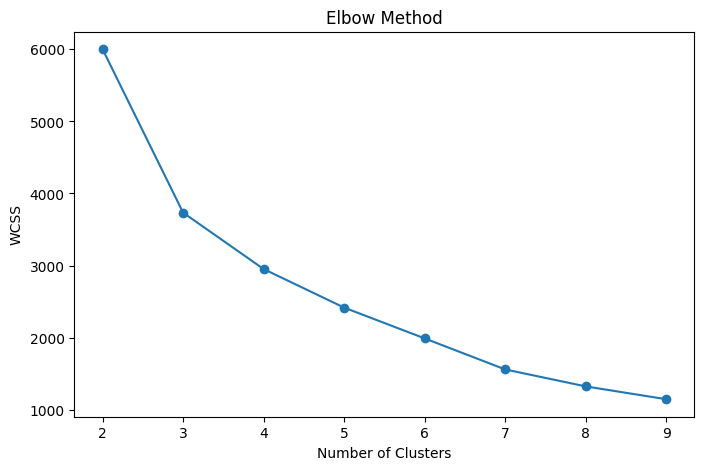

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

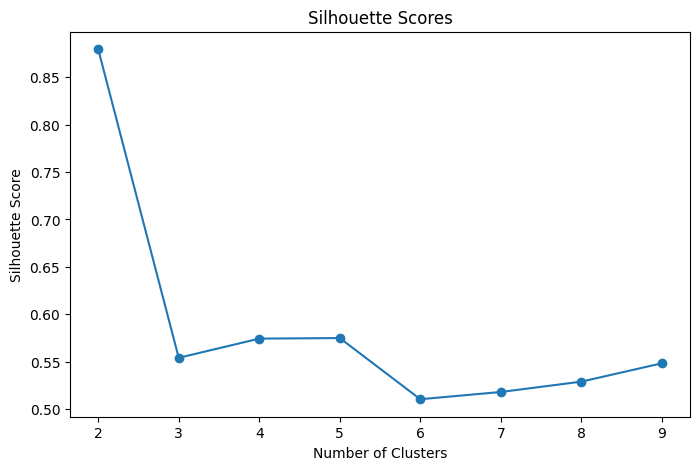

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

### Cluster Selection

The Elbow curve begins to flatten around **k = 4**, indicating that additional clusters provide smaller improvements in WCSS.

Although **k = 2** produces the highest Silhouette Score, a two-cluster solution provides limited detail for targeted marketing.

The Silhouette Scores for **k = 4** and **k = 5** are very similar. A **four-cluster solution** therefore provides a good balance between:

- the Elbow Method,
- cluster separation,
- business interpretability,
- and actionable customer segments.

Therefore, **4 customer segments** were selected for the final K-Means model.

## K-Means Model

In [69]:
selected_k = 4

kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

rfm_df["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm_df["Cluster"]
)

print("Selected number of clusters:", selected_k)
print("Final Silhouette Score:", round(final_silhouette, 4))

Selected number of clusters: 4
Final Silhouette Score: 0.5743


## Cluster Characteristics

In [63]:
cluster_summary = rfm_df.groupby(
    "Cluster"
).agg(
    Customers=("customer_id", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,930,506.22,1.05,106.25
1,2044,108.35,1.07,97.62
2,13,78.38,11.23,3553.69
3,67,183.49,3.99,995.89


The four clusters can be described using their RFM characteristics:

- **Recent / Occasional:** recent customers with low purchase frequency and moderate spending
- **At Risk:** customers whose last purchase was a long time ago
- **Loyal High-Value:** repeat customers with relatively high spending
- **Champions:** very frequent, recent, and very high-value customers

In [64]:
segment_names = {
    0: "At Risk",
    1: "Recent / Occasional",
    2: "Champions",
    3: "Loyal High-Value"
}

rfm_df["Segment"] = rfm_df[
    "Cluster"
].map(segment_names)

rfm_df.head()

,customer_id,Recency,Frequency,Monetary,Cluster,Segment
0,3,160,2,108.72,1,Recent / Occasional
1,4,887,1,29.55,0,At Risk
2,5,614,3,124.99,0,At Risk
3,7,871,1,49.14,0,At Risk
4,8,858,1,69.70,0,At Risk


In [65]:
segment_summary = rfm_df.groupby(
    "Segment"
).agg(
    Customers=("customer_id", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,930,506.22,1.05,106.25
Champions,13,78.38,11.23,3553.69
Loyal High-Value,67,183.49,3.99,995.89
Recent / Occasional,2044,108.35,1.07,97.62


## Cluster Visualization

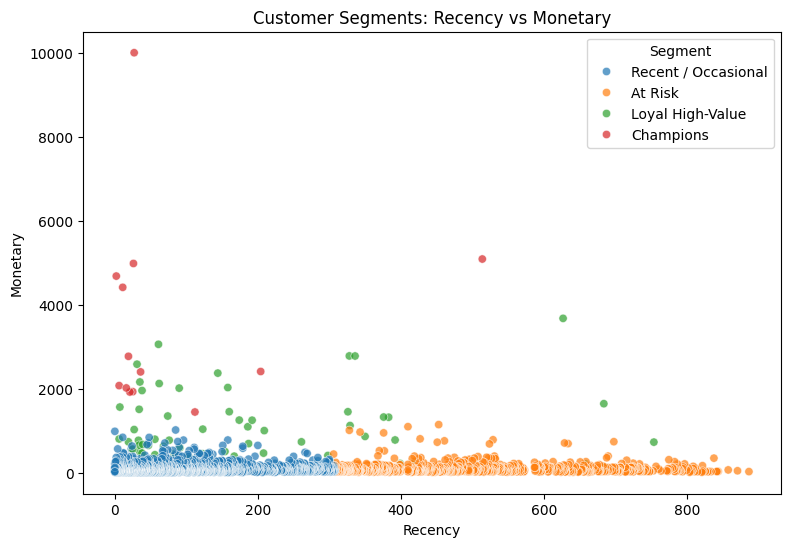

In [66]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm_df,
    x="Recency",
    y="Monetary",
    hue="Segment",
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

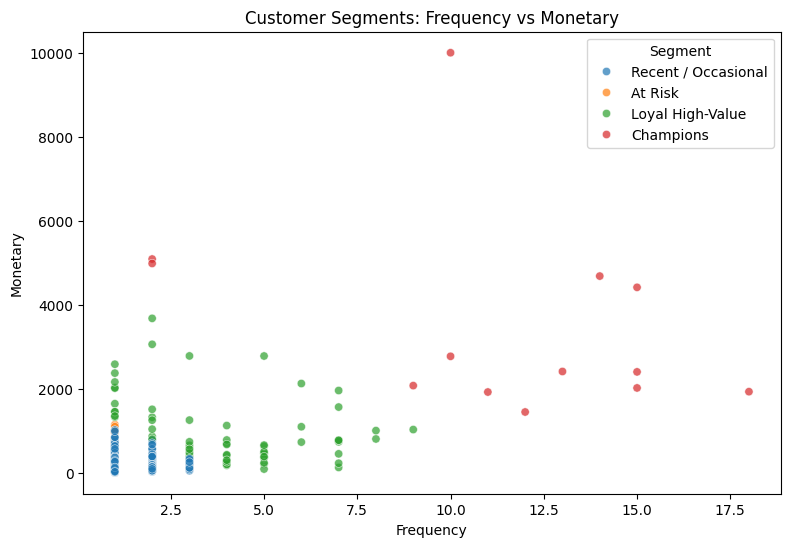

In [67]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm_df,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

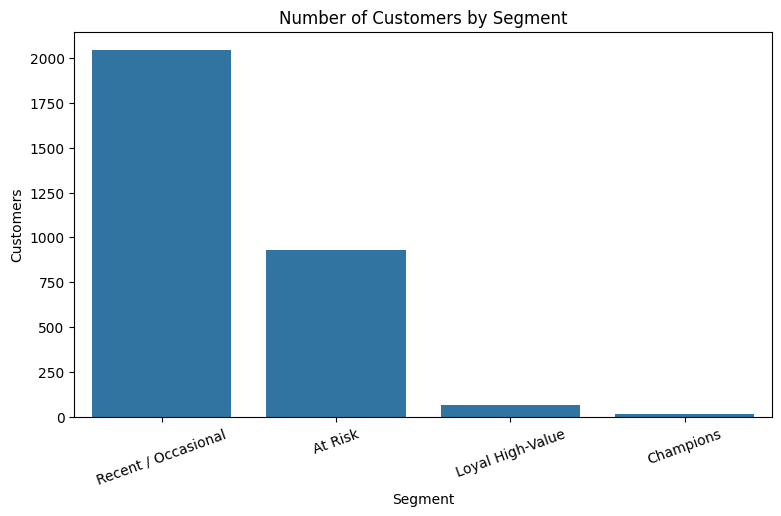

In [68]:
plt.figure(figsize=(9, 5))

segment_counts = (
    rfm_df["Segment"]
    .value_counts()
)

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Number of Customers by Segment")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=20)
plt.show()

## Marketing Interpretation

The segments can support different marketing actions:

| Segment | Main Characteristic | Possible Marketing Action |
| --- | --- | --- |
| **Champions** | Very frequent and high-spending customers | Loyalty rewards, premium offers, early access |
| **Loyal High-Value** | Repeat customers with high spending | Cross-selling, personalized recommendations |
| **Recent / Occasional** | Recent but mostly one-time customers | Encourage a second purchase, follow-up offers |
| **At Risk** | Long time since last purchase | Reactivation campaigns, targeted incentives |

These segment names are business interpretations of the RFM cluster profiles rather than labels provided by the original dataset.

## Conclusion

This project develops a complete customer segmentation workflow using transactional customer data.

The original dataset was separated into **Customers, Orders, and Products** tables, stored in a **SQLite database**, imported again, and merged for further analysis.

An **RFM analysis** was then created for **3,054 customers** using Recency, Frequency, and Monetary values.

The number of customer segments was evaluated using both the **Elbow Method** and **Silhouette Score**. Although a two-cluster solution produced the highest Silhouette Score, it provided limited detail for targeted marketing. A **four-cluster solution** was therefore selected to provide a better balance between statistical separation and business interpretability.

The final K-Means model achieved a **Silhouette Score of 0.5743** and identified four customer segments:

- **Recent / Occasional:** 2,044 customers
- **At Risk:** 930 customers
- **Loyal High-Value:** 67 customers
- **Champions:** 13 customers

The segment profiles show clear differences in purchase recency, frequency, and spending behavior. These groups can support targeted marketing strategies such as customer reactivation, repeat-purchase campaigns, loyalty programs, and premium offers.

Overall, the project demonstrates how RFM analysis and K-Means clustering can transform transactional data into actionable customer segments.